In [58]:
import jax
import jax.numpy as jnp
import numpy as np
from jax.experimental.ode import odeint
import matplotlib.pyplot as plt
from functools import partial # reduces arguments to function by making some subset implicit

from jax.example_libraries import stax
from jax.example_libraries import optimizers

# visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
# from moviepy.video.io.ImageSequenceClip import ImageSequenceClip
from functools import partial
# import proglog
# from PIL import Image

from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

gpu


In [59]:
def equation_of_motion(lagrangian, state, frc, t=None):
  q, q_t = jnp.split(state, 2)
  q_tt = (jnp.linalg.pinv(jax.hessian(lagrangian, 1)(q, q_t, frc))
          @ (jax.grad(lagrangian, 0)(q, q_t, frc) + frc
             - jax.jacobian(jax.jacobian(lagrangian, 1), 0)(q, q_t, frc) @ q_t))
  return jnp.concatenate([q_t, q_tt])

def equation_of_motion_w_frc(lagrangian, state, frc_fn, t):
  q, q_t = jnp.split(state, 2)
  q_tt = (jnp.linalg.pinv(jax.hessian(lagrangian, 1)(q, q_t, frc_fn(t)))
          @ (jax.grad(lagrangian, 0)(q, q_t, frc_fn(t)) + frc_fn(t)
             - jax.jacobian(jax.jacobian(lagrangian, 1), 0)(q, q_t, frc_fn(t)) @ q_t))
  return jnp.concatenate([q_t, q_tt])

def solve_lagrangian(lagrangian, initial_state, forcing, **kwargs):
  # We currently run odeint on CPUs only, because its cost is dominated by
  # control flow, which is slow on GPUs.
  @partial(jax.jit, backend='cpu')
  def f(initial_state):
    # return odeint(partial(equation_of_motion, lagrangian, frc = forcing),
    #               initial_state, **kwargs)
    return odeint(lambda s,t: equation_of_motion(lagrangian, s, forcing),
                  initial_state, **kwargs)
  return f(initial_state)

def normalize_dp(state):
  # wrap generalized coordinates to [-pi, pi]
  return jnp.concatenate([
    # (state[:2] + 0.5) % (1) - 0.5,
    # state[:2] * 0,
    # state[:2],
    (state[0] * 0)[None],
    (state[1])[None],
    # ((state[2] + jnp.pi) % (2 * jnp.pi) - jnp.pi)[None],
    (state[2] * 0)[None],
    state[3:]],
    )
#   return state

def rk4_step(f, x, t, h):
  # one step of runge-kutta integration
  k1 = h * f(x, t)
  k2 = h * f(x + k1/2, t + h/2)
  k3 = h * f(x + k2/2, t + h/2)
  k4 = h * f(x + k3, t + h)
  return x + 1/6 * (k1 + 2 * k2 + 2 * k3 + k4)

Max position: [ 4.13886527 21.35424235  3.14157043]
Max target: [ 1.          1.         12.56637061]
Max velocity: [ 6.06404172 45.50028497 11.39441365]
Max acceleration: [  9.51408695 100.05790568  60.04700271]
Max control: [  9.51408695 109.86790568   1.00078338]


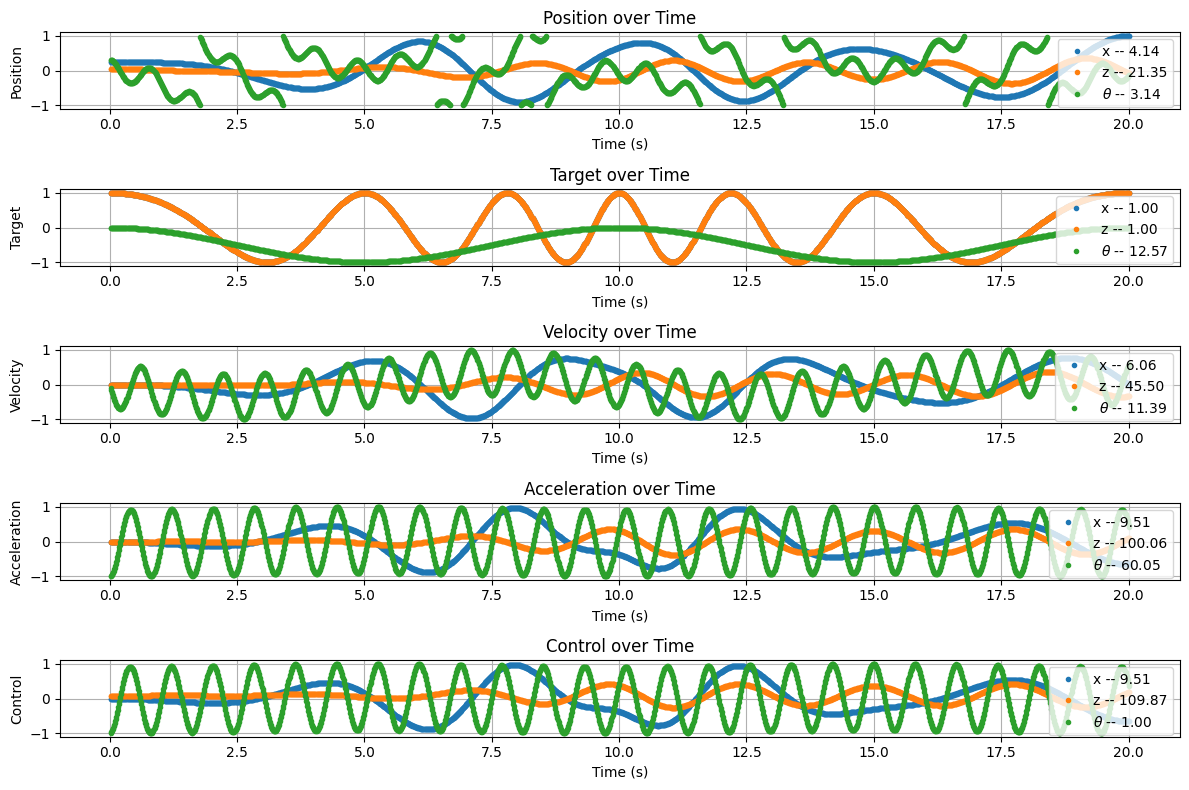

In [60]:
import pickle 

with open('block_simulation_data.pkl', 'rb') as f:
    block_data = pickle.load(f)

pos = jnp.array(block_data['position'])
vel = jnp.array(block_data['velocity'])
acc = jnp.array(block_data['acceleration'])
forces = jnp.array(block_data['control'])


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
keys = ['position', 
        'target', 
        'velocity', 
        'acceleration', 'control']
for i, key in enumerate(keys):
    val_max = np.max(np.abs(block_data[key]), axis=0)

    # import pdb; pdb.set_trace()

    print(f"Max {key}: {val_max.copy()}")
    sim_key = np.array(block_data[key]) / val_max.copy()

    # np.random.shuffle(sim_key)

    plt.subplot(len(keys), 1, i + 1)
    slice_idx = len(block_data['time'])
    slice_idx = 2000
    plt.plot(block_data['time'][:slice_idx], sim_key[:slice_idx,:], linestyle='None', marker='.')
    plt.title(f'{key.capitalize()} over Time')
    plt.xlabel('Time (s)')
    plt.ylabel(key.capitalize())
    plt.legend([f'x -- {val_max[0]:.2f}', 
                f'z -- {val_max[1]:.2f}', 
                fr'$\theta$ -- {val_max[2]:.2f}'], loc='upper right')
    plt.grid()
plt.tight_layout()


In [61]:
import numpy as np

# assume acc, forces are (N,3) NumPy arrays
acc_norm = np.linalg.norm(acc, axis=1)
f_norm   = np.linalg.norm(forces, axis=1)

# pick a percentile cutoff (e.g. drop top 1%)
acc_thr = np.percentile(acc_norm, 99)
f_thr   = np.percentile(f_norm,   99)

# build a boolean mask
keep = (acc_norm < acc_thr) & (f_norm < f_thr)

# apply it to all your arrays
# pos    = pos[keep]
# vel    = vel[keep]
# acc    = acc[keep]
# forces = forces[keep]

# make timeseries copy
pos_ts = pos.copy()
vel_ts = vel.copy()
acc_ts = acc.copy()
forces_ts = forces.copy()

permutation = jax.random.permutation(jax.random.PRNGKey(0), pos.shape[0])
pos = pos[permutation]
# pos = pos.at[:,:2].set(0)
vel = vel[permutation]
acc = acc[permutation]
forces = forces[permutation]

train_test_split = int(0.8 * pos.shape[0])

# x_train = jax.device_get(jnp.concatenate([pos[:train_test_split], vel[:train_test_split]], axis=1))
# xt_train = jax.device_get(jnp.concatenate([vel[:train_test_split], acc[:train_test_split]], axis=1))
# f_train = jax.device_get(forces[:train_test_split])

# x_test = jax.device_get(jnp.concatenate([pos[train_test_split:], vel[train_test_split:]], axis=1))
# xt_test = jax.device_get(jnp.concatenate([vel[train_test_split:], acc[train_test_split:]], axis=1))
# f_test = jax.device_get(forces[train_test_split:])

x_train = jnp.concatenate([pos[:train_test_split], vel[:train_test_split]], axis=1)
xt_train = jnp.concatenate([vel[:train_test_split], acc[:train_test_split]], axis=1)
f_train = forces[:train_test_split]

x_test = jnp.concatenate([pos[train_test_split:], vel[train_test_split:]], axis=1)
xt_test = jnp.concatenate([vel[train_test_split:], acc[train_test_split:]], axis=1)
f_test = forces[train_test_split:]

In [62]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np

# # assume each is (N,3)
# df = pd.DataFrame(
#     np.hstack([pos, vel, acc, forces]),
#     columns=[
#       'x','z','tht',       # pos 
#       'vx','vz','vtht',    # vel
#       'ax','az','atht',    # acc
#       'fx','fz','ftht'     # force
#     ]
# )
# sns.pairplot(df.sample(2000), corner=True)  # sample to speed up
# plt.show()


In [63]:
# import numpy as np
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt

# # assume pos, vel, acc, forces are each (N,3) NumPy arrays
# data = np.hstack([pos, vel, acc, forces])   # shape (N, 12)

# # 1) fit PCA
# pca = PCA(n_components=2)
# proj = pca.fit_transform(data)              # (N, 2)

# # 2) plot
# plt.figure(figsize=(6,6))
# plt.scatter(proj[:,0], proj[:,1], s=5, alpha=0.5)
# plt.xlabel('PC 1')
# plt.ylabel('PC 2')
# plt.title(f'PCA (explained var: {pca.explained_variance_ratio_[:2].sum():.2%})')
# plt.show()


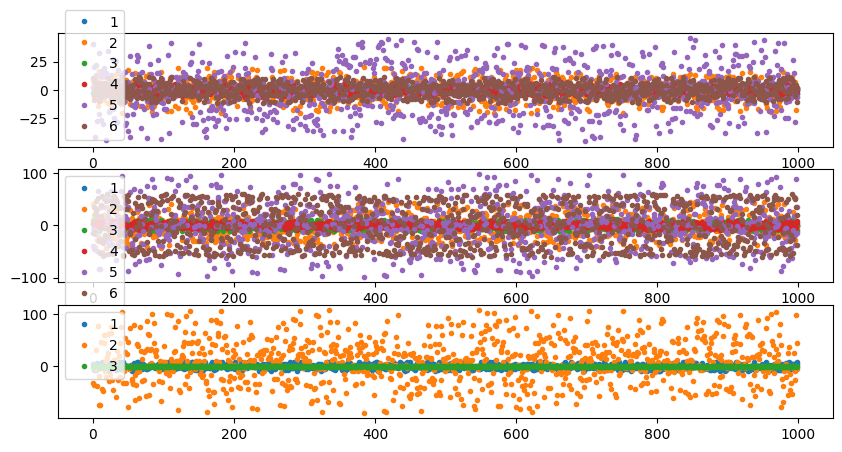

In [64]:
plt.figure(figsize=(10,5))
slc_idx = 1000
plt.subplot(3,1,1)
plt.plot(x_train[:slc_idx,:], linestyle='None', marker='.')
plt.legend([1,2,3,4,5,6])

plt.subplot(3,1,2)
plt.plot(xt_train[:slc_idx,:], linestyle='None', marker='.')
plt.legend([1,2,3,4,5,6])

plt.subplot(3,1,3)
plt.plot(f_train[:slc_idx,:], linestyle='None', marker='.')
plt.legend([1,2,3])

In [65]:
# replace the lagrangian with a parameteric model
def learned_lagrangian(params):
  def lagrangian(q, q_t, frc):
    assert q.shape == (3,)
    inp = normalize_dp(jnp.concatenate([q, q_t, frc]))
    return jnp.squeeze(nn_forward_fn(params, inp), axis=-1)
  return lagrangian

@partial(jax.jit, static_argnums=())
def batch_dynamics(params, states, forces):
    def single_eom(x, f):
        q, q_t = jnp.split(x, 2)
        L = learned_lagrangian(params)
        # use jacfwd+grad instead of full hessian for a 3×3 mass matrix
        M   = jax.jacfwd(jax.grad(L, argnums=1), argnums=1)(q, q_t, f)
        M_reg = M + 1e-2 * jnp.eye(M.shape[-1])   # add small diagonal
        dLdq = jax.grad(L, argnums=0)(q, q_t, f)
        C   = jax.jacfwd(jax.jacobian(L, argnums=1), argnums=0)(q, q_t, f)
        q_tt = jnp.linalg.solve(M_reg, dLdq + f - C @ q_t)
        # q_tt = jnp.linalg.pinv(M) @ (dLdq + f - C @ q_t)
        return jnp.concatenate([q_t, q_tt])
    return jax.vmap(single_eom)(states, forces)

# @jax.jit
# def loss(params, batch):
#     states, targets, forces = batch
#     preds = batch_dynamics(params, states, forces)
#     return jnp.mean((preds - targets) ** 2)

# @jax.jit
# def loss(params, batch):
#     states, targets, forces = batch
#     preds = batch_dynamics(params, states, forces)
#     # L∞ = max |preds − targets|
#     return jnp.max(jnp.abs(preds - targets))

@jax.jit
def loss(params, batch):
    states, targets, forces = batch
    preds = batch_dynamics(params, states, forces)
    # compute |error| per element, then max over last axis (features),
    # then mean over batch axis
    per_sample_max = jnp.max(jnp.abs(preds - targets), axis=tuple(range(1, preds.ndim)))
    return jnp.mean(per_sample_max)


# # define the loss of the model (MSE between predicted q, \dot q and targets)
# @jax.jit
# def loss(params, batch, time_step=None):
#   state, targets, forcing = batch
# #   if time_step is not None:
# #     f = partial(equation_of_motion, learned_lagrangian(params))
# #     preds = jax.vmap(partial(rk4_step, f, t=0.0, h=time_step))(state)
# #   else:
#   preds = jax.vmap(partial(equation_of_motion, learned_lagrangian(params)))(state, forcing)
#   return jnp.mean((preds - targets) ** 2)

# # build a neural network model
# init_random_params, nn_forward_fn = stax.serial(
#     stax.Dense(128),
#     stax.Softplus,
#     stax.Dense(128),
#     stax.Softplus,
#     stax.Dense(1),
# )

from jax.nn import initializers

init_random_params, nn_forward_fn = stax.serial(
    # stax.Dense(128,
    #     W_init=initializers.lecun_normal(), 
    #     b_init=initializers.zeros
    # ),
    stax.Dense(128),
    stax.Softplus,
    stax.Dense(128),
    stax.Softplus,
    stax.Dense(128),
    stax.Softplus,
    stax.Dense(1),
)

In [66]:
@jax.jit
def update_timestep(i, opt_state, batch):
  params = get_params(opt_state)
  return opt_update(i, jax.grad(loss)(params, batch, time_step), opt_state)

@jax.jit
def update_derivative(i, opt_state, batch):
  params = get_params(opt_state)
  return opt_update(i, jax.grad(loss)(params, batch, None), opt_state)

# x_train = jax.device_put(jax.vmap(normalize_dp)(x_train))
# y_train = jax.device_put(y_train)

# x_test = jax.device_put(jax.vmap(normalize_dp)(x_test))
# y_test = jax.device_put(y_test)

x_train = jax.vmap(normalize_dp)(x_train)
x_test = jax.vmap(normalize_dp)(x_test)


In [67]:
# %%time

# rng = jax.random.PRNGKey(0)
# _, init_params = init_random_params(rng, (-1, 9))

# # numbers in comments denote stephan's settings
# batch_size = 100
# test_every = 10
# num_batches = 1500

# train_losses = []
# test_losses = []

# # adam w learn rate decay
# opt_init, opt_update, get_params = optimizers.adam(
#     lambda t: jnp.select([t < batch_size*(num_batches//3),
#                           t < batch_size*(2*num_batches//3),
#                           t > batch_size*(2*num_batches//3)],
#                          [1e-2, 3e-4, 1e-4]))
# opt_state = opt_init(init_params)

# for iteration in range(batch_size*num_batches + 1):
#   if iteration % batch_size == 0:
#     params = get_params(opt_state)
#     train_loss = loss(params, (x_train, xt_train, f_train))
#     train_losses.append(train_loss)
#     test_loss = loss(params, (x_test, xt_test, f_test))
#     test_losses.append(test_loss)
#     if iteration % (batch_size*test_every) == 0:
#       print(f"iteration={iteration}, train_loss={train_loss:.6f}, test_loss={test_loss:.6f}")
#   opt_state = update_derivative(iteration, opt_state, (x_train, xt_train, f_train))

# params = get_params(opt_state)

In [71]:
# %%time
import optax
from optax import exponential_decay
from optax.schedules import sgdr_schedule

rng = jax.random.PRNGKey(0)
_, init_params = init_random_params(rng, (-1, 9))

# numbers in comments denote stephan's settings
batch_size = 256
test_every = 10
num_batches = 1500 * 20

train_losses = []
test_losses = []
gns = []
lrs = []

# lr_schedule = exponential_decay(
#   init_value=1e-1,           # start LR
#   transition_steps=1000,     # how many steps per decay
#   decay_rate=0.9,            # multiply by 0.9 each “transition”
#   end_value=1e-4             # never go below this
# )                            # :contentReference[oaicite:0]{index=0}

total_steps = batch_size * num_batches
# n_cycles    = 5
# cycle_len   = total_steps // n_cycles

# c_kwargs = [{
#     "init_value": 3e-3,   # ← lower peak 
#     "peak_value": 3e-3,
#     "warmup_steps": 0,
#     "decay_steps": cycle_len,
#     "end_value": 1e-4,    # smaller floor
# } for _ in range(n_cycles)]
# lr_schedule = sgdr_schedule(cosine_kwargs=c_kwargs)

lr_schedule = optax.cosine_decay_schedule(
  init_value=5e-3, decay_steps=total_steps, alpha=1e-5
)

# optimizer = optax.adamw(
#   learning_rate=lr_schedule,
#   weight_decay=1e-3
# )

optimizer = optax.chain(
  optax.clip_by_global_norm(10),
  optax.adamw(learning_rate=lr_schedule, weight_decay=1e-4),
)

opt_state = optimizer.init(init_params)
params = init_params

@jax.jit
def train_step(params, opt_state, batch, step):
    grads = jax.grad(loss)(params, batch)
    gn = optax.global_norm(grads)
    lr = lr_schedule(step)
    # jax.debug.print("step={s}  lr={lr:.2e}  grad_norm={gn:.2e}",
    #                 s=step, lr=lr, gn=gn, ordered=True)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, gn, lr

min_loss = 1e10
min_loss_params = None

for iteration in range(batch_size*num_batches + 1):
  if iteration % batch_size == 0:
    # params = get_params(opt_state)
    train_loss = loss(params, (x_train, xt_train, f_train))
    train_losses.append(train_loss)
    test_loss = loss(params, (x_test, xt_test, f_test))
    test_losses.append(test_loss)
    if iteration % (batch_size*test_every) == 0:
      print(f"iteration={iteration}, train_loss={train_loss:.6f}, test_loss={test_loss:.6f}, lr={lr_schedule(iteration):.6f}")
#   opt_state = update_derivative(iteration, opt_state, (x_train, xt_train, f_train))
    params, opt_state, gn, lr = train_step(params, opt_state, (x_train, xt_train, f_train), iteration)
    gns.append(gn)
    lrs.append(lr)

    if test_loss < min_loss:
      min_loss = test_loss
      min_loss_params = params

# params = get_params(opt_state)

iteration=0, train_loss=4805.756348, test_loss=4750.454102, lr=0.005000
iteration=2560, train_loss=303.557678, test_loss=304.687927, lr=0.005000
iteration=5120, train_loss=40.460304, test_loss=39.945644, lr=0.005000
iteration=7680, train_loss=37.130116, test_loss=36.900509, lr=0.005000
iteration=10240, train_loss=26.680067, test_loss=26.480471, lr=0.005000
iteration=12800, train_loss=17.318171, test_loss=17.386490, lr=0.005000
iteration=15360, train_loss=13.803005, test_loss=13.781052, lr=0.005000
iteration=17920, train_loss=12.351842, test_loss=12.395624, lr=0.005000
iteration=20480, train_loss=11.493876, test_loss=11.553412, lr=0.005000
iteration=23040, train_loss=11.054646, test_loss=11.083842, lr=0.005000
iteration=25600, train_loss=10.698656, test_loss=10.737741, lr=0.005000
iteration=28160, train_loss=10.322577, test_loss=10.334517, lr=0.005000
iteration=30720, train_loss=9.816002, test_loss=9.864215, lr=0.005000
iteration=33280, train_loss=10.153329, test_loss=10.217958, lr=0.00

KeyboardInterrupt: 

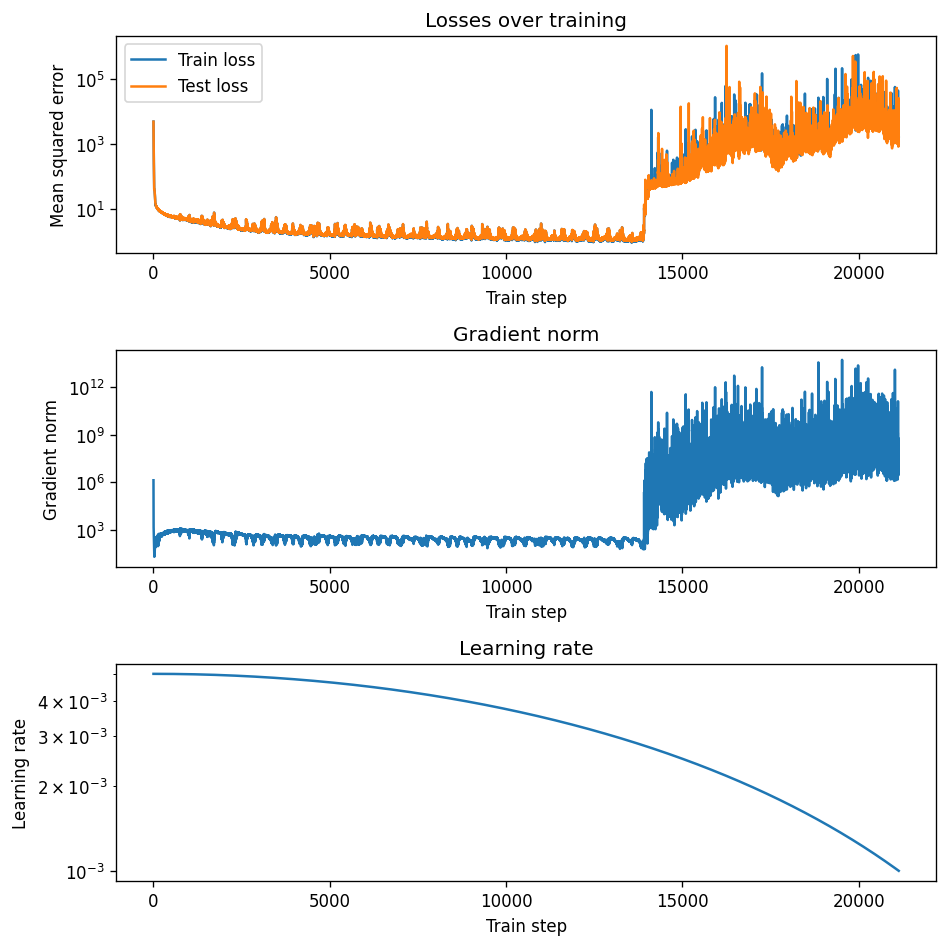

In [72]:
plt.figure(figsize=(8, 8), dpi=120)
plt.subplot(3, 1, 1)
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test loss')
plt.yscale('log')
# plt.ylim(None, 2e6)
plt.title('Losses over training')
plt.xlabel("Train step") ; plt.ylabel("Mean squared error")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(gns)
plt.title('Gradient norm')
plt.xlabel("Train step") ; plt.ylabel("Gradient norm")
plt.yscale('log')
plt.subplot(3, 1, 3)
plt.plot(lrs)
plt.title('Learning rate')
plt.xlabel("Train step") ; plt.ylabel("Learning rate")
plt.yscale('log')
# plt.ylim(1e-5, None)
plt.tight_layout()

plt.show()

Min test loss: 0.971612


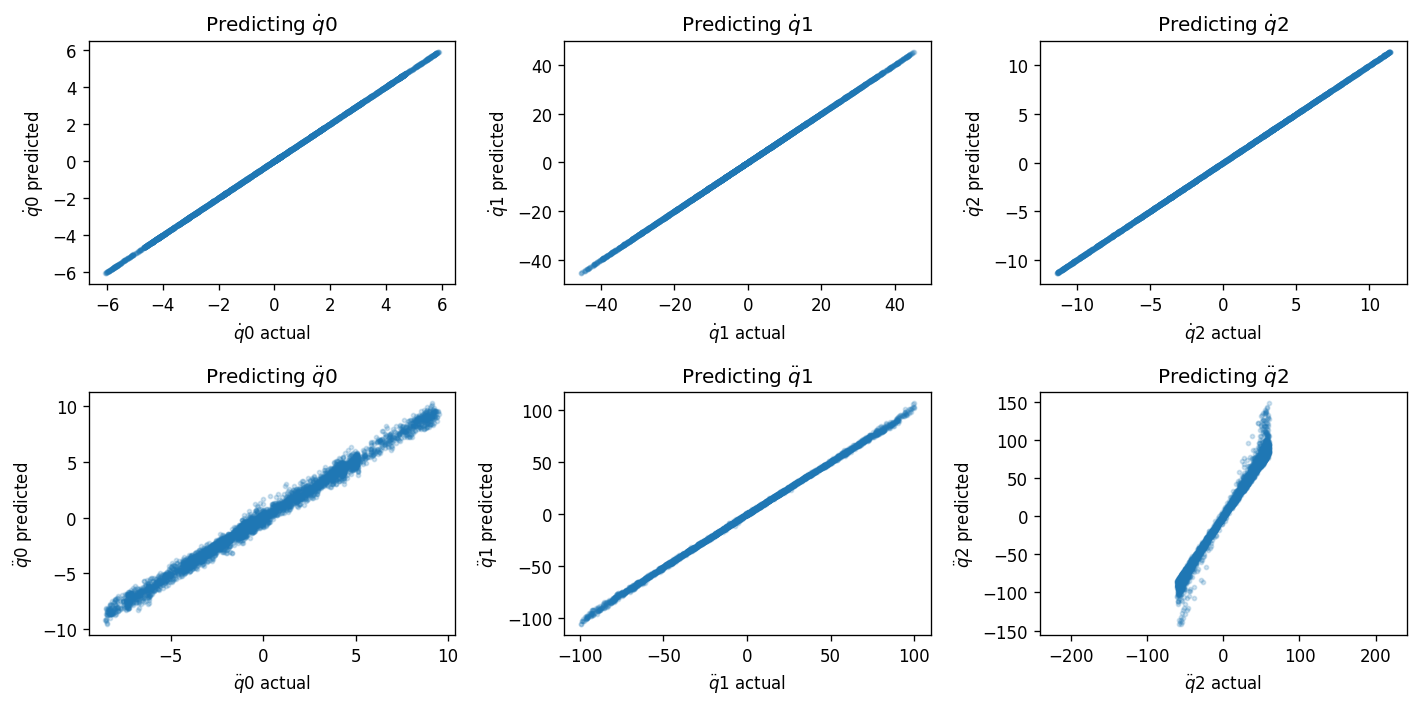

In [73]:
# xt_pred = jax.vmap(partial(equation_of_motion, learned_lagrangian(params)))(x_test, f_test)

print(f"Min test loss: {min_loss:.6f}")
xt_pred = jax.vmap(partial(equation_of_motion, learned_lagrangian(min_loss_params)))(x_test, f_test)


sampl = xt_pred.shape[0]


k = 0
fig, axes = plt.subplots(2, 3, figsize=(12,6), dpi=120)
for i in range(2):
    for j in range(3):
        axes[i][j].scatter(xt_test[:sampl, k], xt_pred[:sampl, k], s=6, alpha=0.2)
        deriv = r'\dot' if i == 0 else r'\ddot'
        axes[i][j].set_title(fr'Predicting ${deriv} q{j}$')
        axes[i][j].set_xlabel(fr'${deriv} q{j}$ actual')
        axes[i][j].set_ylabel(fr'${deriv} q{j}$ predicted')
        plt.axis('equal')
        k += 1
plt.tight_layout()
plt.show()

In [ ]:
# choose an initial state
x1 = np.array([0, 0, 0, 0, 0, 0], dtype=np.float32)
forcing = np.array([0, 0, 0], dtype=np.float32)

t2 = np.linspace(0, 1, num=10)
noise_coeff_3 = 1e-3
%time x1_model = jax.device_get(solve_lagrangian(learned_lagrangian(params), x1, forcing, t=t2))

In [13]:
with open('model_parms.pkl', 'wb') as f:
    pickle.dump(params, f)

In [9]:
with open('model_parms.pkl', 'rb') as f:
    params = pickle.load(f)

In [14]:
print(f"fx:{jnp.max(jnp.abs(forces[:,0]))}, fz:{jnp.max(jnp.abs(forces[:,1]))}, ftht:{jnp.max(jnp.abs(forces[:,2]))}")

fx:1.507487177848816, fz:16.379995346069336, ftht:1.23508620262146


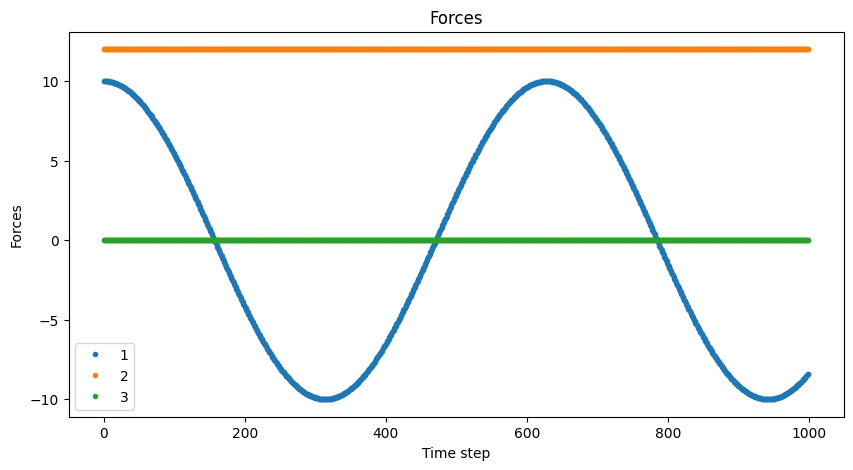

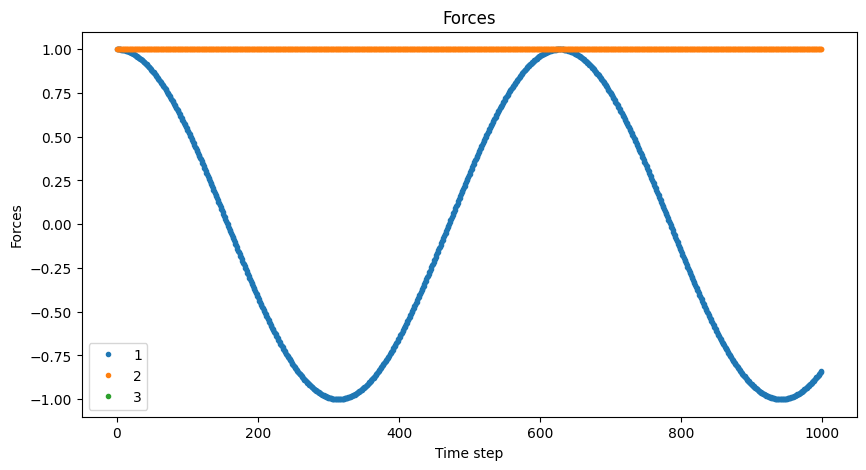

In [54]:
forcing_res =[]
# forcing_fn = lambda t: np.array([np.cos(t), 2 * np.sin(t) + 8, np.sin(t)], dtype=np.float32)
forcing_fn = lambda t: np.array([10 * np.cos(t) , 12, 0* 0.2 * np.sin(t) ], dtype=np.float32)

for i in jnp.linspace(0,10, num=1000):
    forcing = forcing_fn(i)
    # print(f"fx:{forcing[0]}, fz:{forcing[1]}, ftht:{forcing[2]}")
    forcing_res.append(forcing)

forcing_res = np.array(forcing_res)
forcing_res

plt.figure(figsize=(10,5))
plt.plot(forcing_res, linestyle='None', marker='.')
plt.legend([1,2,3])
plt.title('Forces')
plt.xlabel("Time step") ; plt.ylabel("Forces")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(forcing_res/jnp.max(jnp.abs(forcing_res), axis=0), linestyle='None', marker='.')
plt.legend([1,2,3])
plt.title('Forces')
plt.xlabel("Time step") ; plt.ylabel("Forces")
plt.show()

In [55]:
x0 = jnp.concatenate([jnp.mean(pos, axis=0), jnp.mean(vel, axis=0)])
tsteps = np.linspace(0, 5, num=200)
# integrate learned lagrangian using rk4
# f = partial(equation_of_motion_w_frc, learned_lagrangian(params), frc_fn=forcing_fn)
f = lambda state, t: equation_of_motion_w_frc(
    learned_lagrangian(params),   # lagrangian
    state,                        # state
    forcing_fn,                   # frc_fn
    t                             # time
)

xs = []

for i, tim in enumerate(tsteps):
    x0 = rk4_step(f, x0, i, tsteps[1]).copy()
    # x0 = rk4_step_jit(f, x0, tim, 0.01)
    # print(x0.device)
    xs.append(x0)
    print(f"t={tim:.3f},{i}/{tsteps.shape[0]}", end='\n')
    # print(x0)

t=0.000,0/200
t=0.025,1/200
t=0.050,2/200
t=0.075,3/200
t=0.101,4/200
t=0.126,5/200
t=0.151,6/200
t=0.176,7/200
t=0.201,8/200
t=0.226,9/200
t=0.251,10/200
t=0.276,11/200
t=0.302,12/200
t=0.327,13/200
t=0.352,14/200
t=0.377,15/200
t=0.402,16/200
t=0.427,17/200
t=0.452,18/200
t=0.477,19/200
t=0.503,20/200
t=0.528,21/200
t=0.553,22/200
t=0.578,23/200
t=0.603,24/200
t=0.628,25/200
t=0.653,26/200
t=0.678,27/200
t=0.704,28/200
t=0.729,29/200
t=0.754,30/200
t=0.779,31/200
t=0.804,32/200
t=0.829,33/200
t=0.854,34/200
t=0.879,35/200
t=0.905,36/200
t=0.930,37/200
t=0.955,38/200
t=0.980,39/200
t=1.005,40/200
t=1.030,41/200
t=1.055,42/200
t=1.080,43/200
t=1.106,44/200
t=1.131,45/200
t=1.156,46/200
t=1.181,47/200
t=1.206,48/200
t=1.231,49/200
t=1.256,50/200
t=1.281,51/200
t=1.307,52/200
t=1.332,53/200
t=1.357,54/200
t=1.382,55/200
t=1.407,56/200
t=1.432,57/200
t=1.457,58/200
t=1.482,59/200
t=1.508,60/200
t=1.533,61/200
t=1.558,62/200
t=1.583,63/200
t=1.608,64/200
t=1.633,65/200
t=1.658,66/200
t=1.6

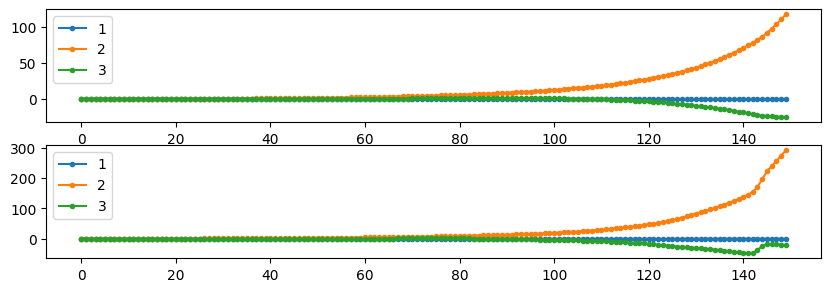

In [56]:
xs = np.array(xs[:])

cutoff = 150

plt.figure(figsize=(10,5))
plt.subplot(3,1,1)
plt.plot(xs[:cutoff,:3], linestyle='-', marker='.')
plt.legend([1,2,3])

plt.subplot(3,1,2)
plt.plot(xs[:cutoff,3:6], linestyle='-', marker='.')
plt.legend([1,2,3])

In [15]:
# choose an initial state
x1 = np.array([0, 0, 0, 0, 0, 0], dtype=np.float32)
forcing = np.array([0, 0, 0], dtype=np.float32)

# learned_lagrangian(params)(x1[:3], x1[3:], forcing)
equation_of_motion(learned_lagrangian(params), x1, forcing)

Array([  0.        ,   0.        ,   0.        ,  -0.02097207,
       -10.191847  ,   0.72350246], dtype=float32)

In [ ]:
t2 = np.linspace(0, 5, num=50)
%time x1_model = jax.device_get(solve_lagrangian(learned_lagrangian(params), x1, forcing, t=t2))

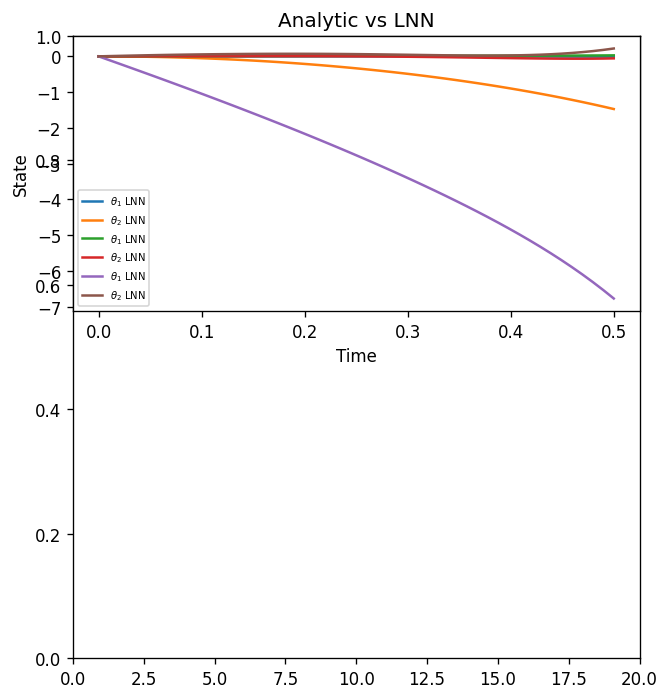

In [25]:
plt.figure(figsize=[6,6], dpi=120) ; plt.xlim(0, 20)
plt.subplot(2,1,1)
plt.title("Analytic vs LNN")
plt.xlabel("Time") ; plt.ylabel("State")
# plt.plot(t2, x1_analytical[:, 2], 'g-', label=r'$\theta_1$ exact')
# plt.plot(t2, x1_analytical[:, 3], 'c-', label=r'$\theta_2$ exact')
plt.plot(t2, x1_model[:, 0],  label=r'$\theta_1$ LNN')
plt.plot(t2, x1_model[:, 1],  label=r'$\theta_2$ LNN')
plt.plot(t2, x1_model[:, 2],  label=r'$\theta_1$ LNN')
plt.plot(t2, x1_model[:, 3],  label=r'$\theta_2$ LNN')
plt.plot(t2, x1_model[:, 4],  label=r'$\theta_1$ LNN')
plt.plot(t2, x1_model[:, 5],  label=r'$\theta_2$ LNN')
plt.legend(fontsize=6)

plt.tight_layout() ; plt.show()